# Tutorial on the hierarchy of hypergraph NMI measures

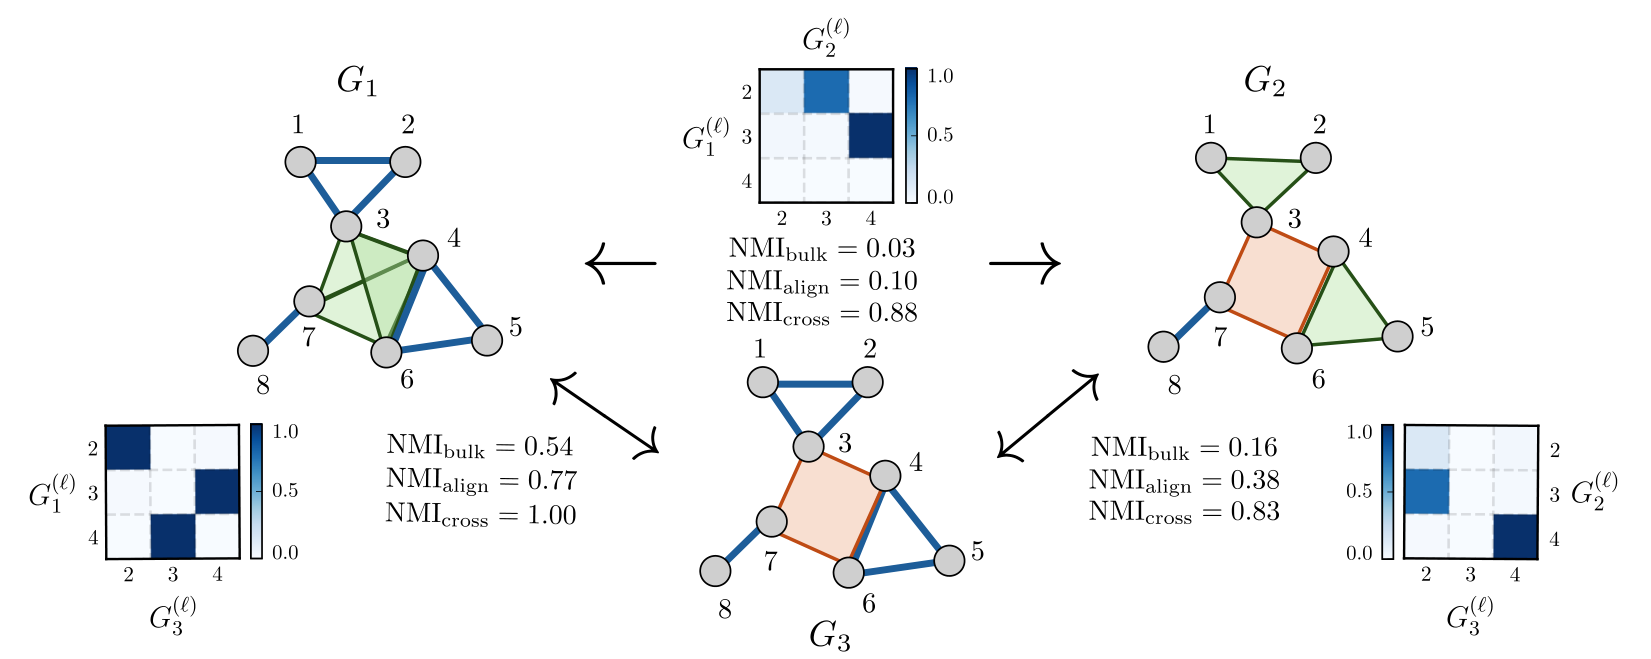

### Import functions

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

from functions import *
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

### Hypegraphs

In [2]:
N = 8
G1 = {(1,2),(2,3),(1,3),(4,5),(5,6),(4,6),(7,8),(3,4,6),(3,4,7),(4,6,7),(3,6,7)}
G2 = {(1,2,3),(4,5,6),(3,4,6,7),(7,8)}
G3 = {(1,2),(2,3),(1,3),(4,5),(4,6),(5,6),(3,4,6,7),(7,8)}

#### $\textrm{NMI}_{c}$ values

In [3]:
print(f"NMIbulk  = {float(NMIbulk(N, G1, G2)):.2f}", #convert to float due to `mpf`
      f"NMIalign = {float(NMIalign(G1, G2)):.2f}",
      f"NMIcross = {float(NMIcross(G1, G2)):.2f}",
      sep="\n")

NMIbulk  = 0.03
NMIalign = 0.10
NMIcross = 0.88


#### Order-order matrix $\text{I}_{mn}$ matrix, where

$$
\text{I}_{mn} = \text{H}_b(p_m)+\text{H}_b(p_{n})-\text{H}_s(\textbf{P}_{mn}) ~ .
$$


I_mn = 
 [[1.43903447e-001 7.70949226e-001 9.97300393e-003]
 [2.61015098e-002 1.31115877e-002 1.00000000e+000]
 [6.49029912e-100 6.49029912e-100 1.33554191e-099]] 



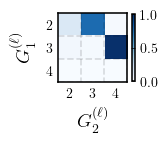

In [4]:
L, lmax = 2, 4
M = np.ones((lmax-1, lmax-1))

"""2-step filling process of M"""
for m in range(M.shape[0]):
    for n in range(m, M.shape[1]):
        e1 = set([e for e in G1 if len(e) == L+n])
        e2 = set([e for e in G2 if len(e) == L+m])
        M[n,m] = hNMI_project(N, e1, e2, L+m)
for m in range(M.shape[0]):
    for n in range(m+1, M.shape[1]):
        e1 = set([e for e in G2 if len(e) == L+n])
        e2 = set([e for e in G1 if len(e) == L+m])
        M[m,n] = hNMI_project(N, e1, e2, L+m)
        
plt.figure(figsize=(1.125,1.125))
plt.imshow(M,cmap="Blues",vmin=0, vmax=1)
plt.xlabel('$G_2^{(\ell)}$',fontsize=14,labelpad=5),plt.ylabel('$G_1^{(\ell)}$',fontsize=14,labelpad=7.5)
plt.xticks([0,1,2], labels=[2,3,4], fontsize=10) 
plt.yticks([0,1,2], labels=[2,3,4], fontsize=10)
plt.tick_params(axis='both', length=0.0)
plt.colorbar(shrink=0.775)
num_rows, num_cols = M.shape # draw thin lines between entries
for i in range(num_rows): # horizontal
    plt.hlines(i+0.5, xmin=-0.5, xmax=num_cols-0.5, color='k',lw=1.25,alpha=0.125,ls="--",zorder=0)
for i in range(num_cols): # vertical
    plt.vlines(i+0.5, ymin=-0.5, ymax=num_rows-0.5, color='k',lw=1.25,alpha=0.125,ls="--",zorder=0)

print(f"I_mn = \n {M} \n")